In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import os
import sklearn
from pathlib import Path
import pickle as pkl
import sys
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import csv
from sklearn.metrics import mean_squared_error, r2_score
import calendar

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)
import xgboost
print("xgboost version:", xgboost.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

Python version: 3.10.9 | packaged by conda-forge | (main, Feb  2 2023, 20:14:58) [MSC v.1929 64 bit (AMD64)]
NumPy version: 1.23.3
Pandas version: 1.5.3
scikit-learn version: 1.2.2
xgboost version: 1.7.4
Matplotlib version: 3.7.1


In [2]:
# load .py file with all functions
from function_XGB import *
cwd = os.getcwd()
print("Current working directory: ", cwd)


Python version: 3.10.9 | packaged by conda-forge | (main, Feb  2 2023, 20:14:58) [MSC v.1929 64 bit (AMD64)]
NumPy version: 1.23.3
Pandas version: 1.5.3
scikit-learn version: 1.2.2
xgboost version: 1.7.4
Matplotlib version: 3.7.1
Current working directory:  f:\NEON_gapfill


# Define working directory

In [3]:
sitename = "BART_NEON"
site_data_dir = Path(f"F:/NEON_gapfill/") # local working directory
# site_data_dir = Path("/home/jovyan") # binder working directory
model_dir = site_data_dir / "XGB_models"
model_dir.mkdir(exist_ok=True)

# Load data




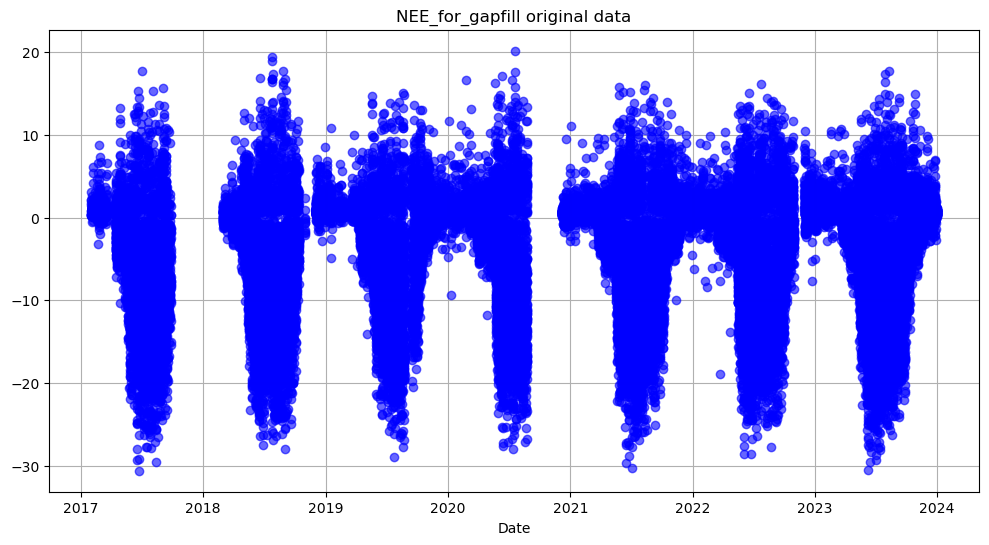

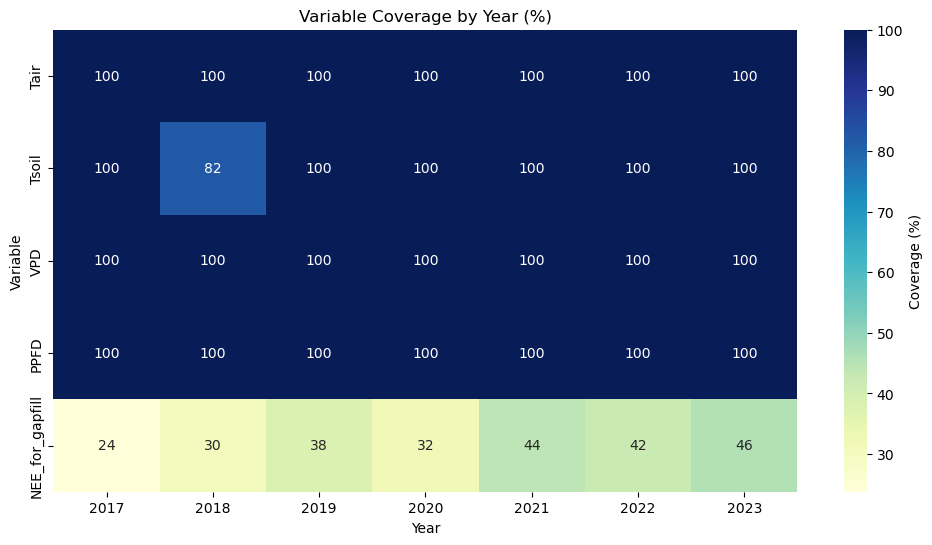

In [4]:
predictors = ['TIMESTAMP_END', 'GCC', 'EVI', 'Tair', 'VPD', 'PPFD']
y_col = "NEE_for_gapfill"
file_name = "data_for_XGB_BART_NEON.csv"
site_data = load_data(site_data_dir, file_name, y_col, plot=True)

# 01 Find the best hyperparameters

The `find_hyperparameters` function is designed to optimize an XGBoost regression model by performing a grid search over a predefined set of hyperparameters using 10-fold cross-validation. It returns the trained model as `.pkl` for future use.

Parameters:

- `site_data_no_na` (*DataFrame*): Cleaned data (no NA values in `y_col`).  
- `predictors` (*list of str*): Column names to be used as predictors (X).  
- `y_col` (*str*): Name of the response variable (y).  
- `model_dir` (*Path* or *str*): Directory to save the model and best parameters.  
- `n_jobs` (*int*): Number of parallel jobs for GridSearchCV.  


In [5]:
# HPC users: If running on a multi-core system, limit thread usage
# to prevent oversubscription (set environment variables before importing packages)
# Uncomment and adjust as needed:

# os.environ['OMP_NUM_THREADS'] = '1'
# os.environ['MKL_NUM_THREADS'] = '1'
# os.environ['OPENBLAS_NUM_THREADS'] = '1'
# os.environ['BLIS_NUM_THREADS'] = '1'

# Set n_jobs based on HPC scheduler:
# n_jobs = int(os.getenv("SLURM_CPUS_PER_TASK", 1))

# This line takes a long time to run (> 5 hours), please keep it commented for the tutorial
# Google colab:
# find_hyperparameters(site_data, predictors, y_col, model_dir, n_jobs = 10)

# HPC:
# find_hyperparameters(site_data, predictors, y_col, model_dir, n_jobs = int(os.getenv("SLURM_CPUS_PER_TASK", 1)))

# Instead, load the model after hyperparameter tuning
model_path = model_dir / f"XGB_model_{y_col}.pkl"
reg = joblib.load(model_path) 

# 02 Check model performance


In [6]:
# check_model_performance(site_data, predictors, y_col, reg, n_folds= 2)

# 03 Gapfill

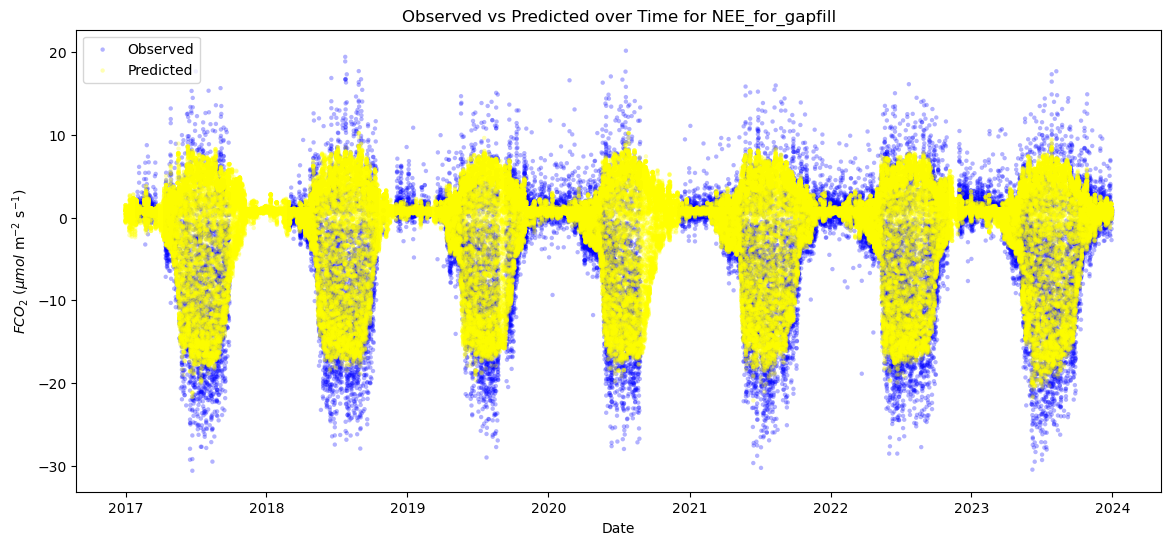

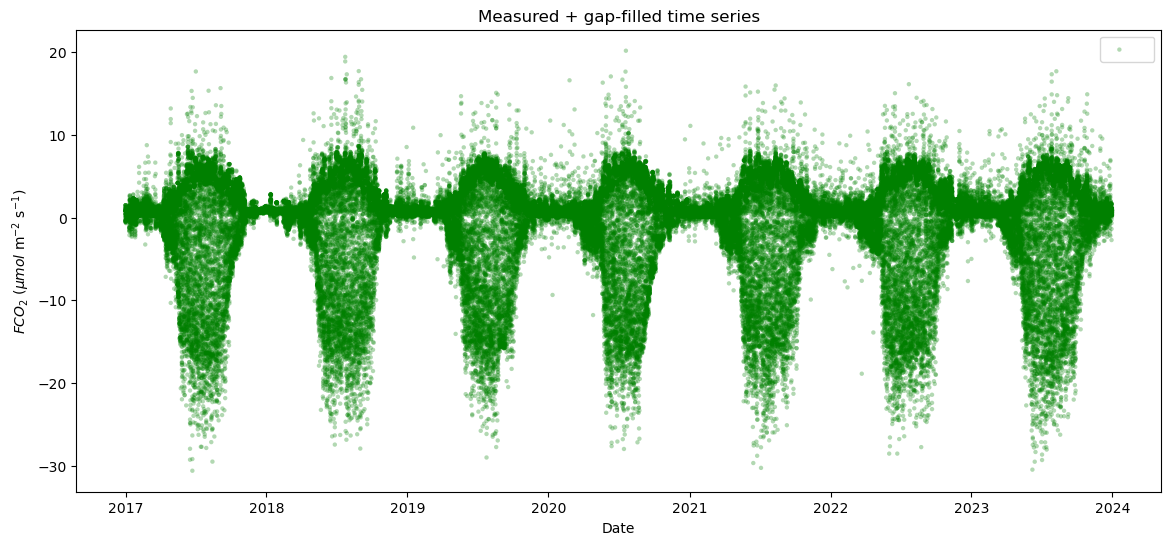

In [7]:
df_pred_FC = get_accurate_prediction(site_data, predictors, y_col, reg, plot=True)

# 04 Feature importances
**Parameters**

- `site_data_no_na` (`pandas.DataFrame`)  
  Input dataset with no missing values.

- `predictors` (`list` of `str`)  
  List of column names in `site_data_no_na` to be used as predictors (features).

- `y_col` (`str`)  
  Column name of the target variable in `site_data_no_na`.

- `site_data_dir` (`pathlib.Path`)  
  Directory where the feature importance CSV (and optionally plots) will be saved.

- `reg` (`object`)  
  Regression model with `fit`, `predict`, and `feature_importances_` attributes  
  (e.g., `XGBRegressor`).


**Returns**

- `pandas.DataFrame`  
  DataFrame containing features and their importance values, sorted in descending order.


In [8]:
# check_feature_importance(site_data, predictors, y_col, reg)

# 05 Compute annual sums and monthly sums

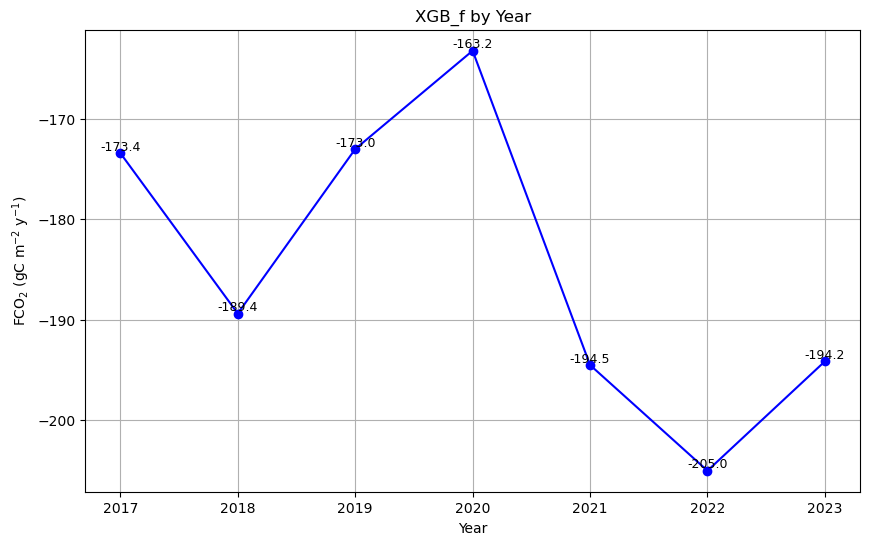

,Year,annual_sum
0,2017,-173.432357
1,2018,-189.398174
2,2019,-173.030032
3,2020,-163.244639
4,2021,-194.520744
5,2022,-205.038860
6,2023,-194.154325


In [9]:
cal_FC_annual_sum(df_pred_FC, "XGB_f", 2017, 2023, plot = True)

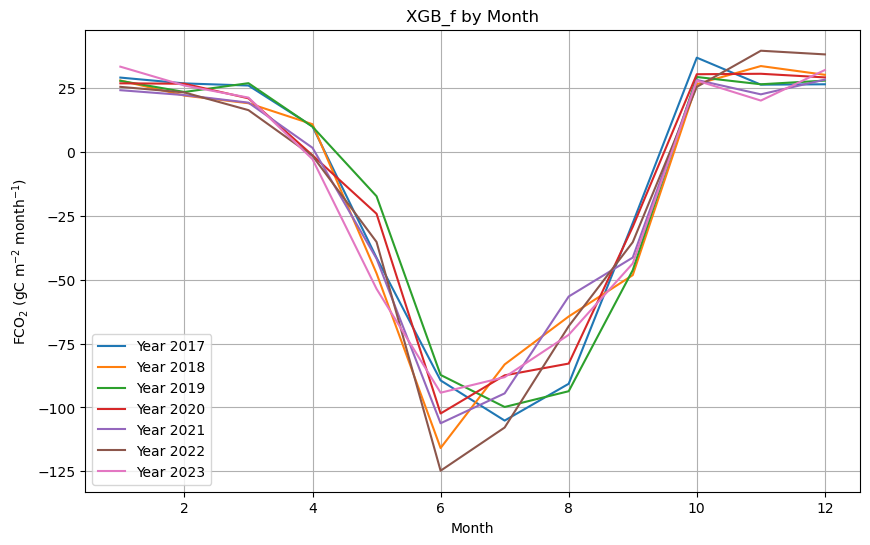

,Year,Month,monthly_sum
0,2017,1,29.042163
1,2017,2,26.762922
2,2017,3,25.932826
3,2017,4,9.930832
4,2017,5,-41.450485
...,...,...,...
79,2023,8,-71.600762
80,2023,9,-43.676442
81,2023,10,27.863257
82,2023,11,20.049091


In [10]:
cal_FC_monthly_sum(df_pred_FC, "XGB_f", 2017, 2023, plot=True)

# 06 Uncertainty analysis (experimental)

In [11]:
boot_list = get_synthetic_data(
    original_data=site_data,
    n_bootstrap=50, #  Number of synthetic datasets to generate
    drop_fraction=0.33, #  Fraction of rows to randomly drop before bootstrap sampling
    sample_size= int(0.8 * len(site_data)), # Number of rows to sample in each bootstrap dataset
    gapfill_cols= "NEE_for_gapfill",
    random_state=42
)

In [12]:
synthetic_predictions = train_on_synthetic_predict(site_data, boot_list, predictors, y_col, model_dir)

In [13]:
# List to store annual sums for each bootstrap
annual_sums_list = []

for col in synthetic_predictions.columns:
    # Create a temporary dataframe with predictions
    temp_df = site_data.copy()
    temp_df['Pred'] = synthetic_predictions[col]

    # Compute annual sums
    agg = cal_FC_annual_sum(
        data=temp_df,
        var_name='Pred',
        start_year=2017,
        end_year=2023,
        plot = False
    )

    # Keep only Year and annual_sum
    annual_sums_list.append(agg[['Year', 'annual_sum']])

# Combine all bootstraps
all_annual_sums = pd.concat(annual_sums_list, axis=1)

# The concatenation duplicates Year columns, so keep the first one and use the rest as data
years = all_annual_sums.iloc[:, 0]
annual_values = all_annual_sums.iloc[:, 1::2]  # Every second column is annual_sum

# Compute mean and std across bootstraps (synthetic datata) for each year
mean_vals = annual_values.mean(axis=1)
std_vals = annual_values.std(axis=1)

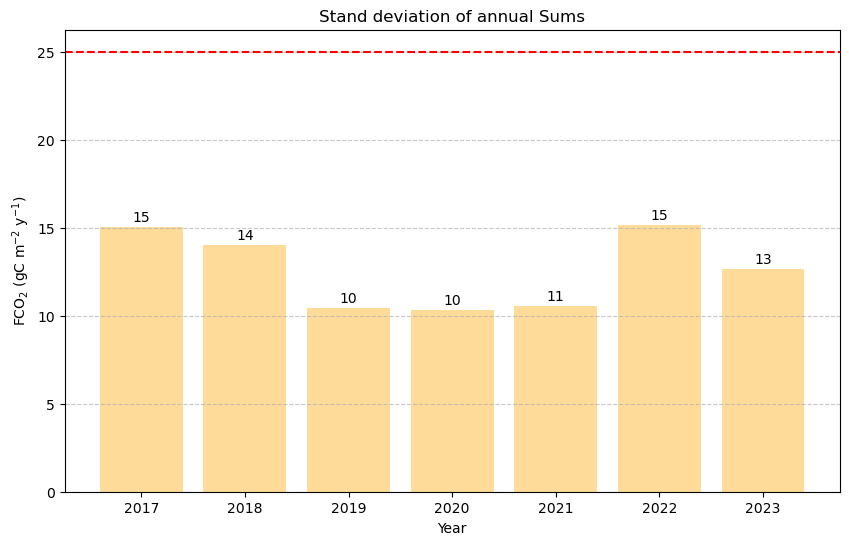

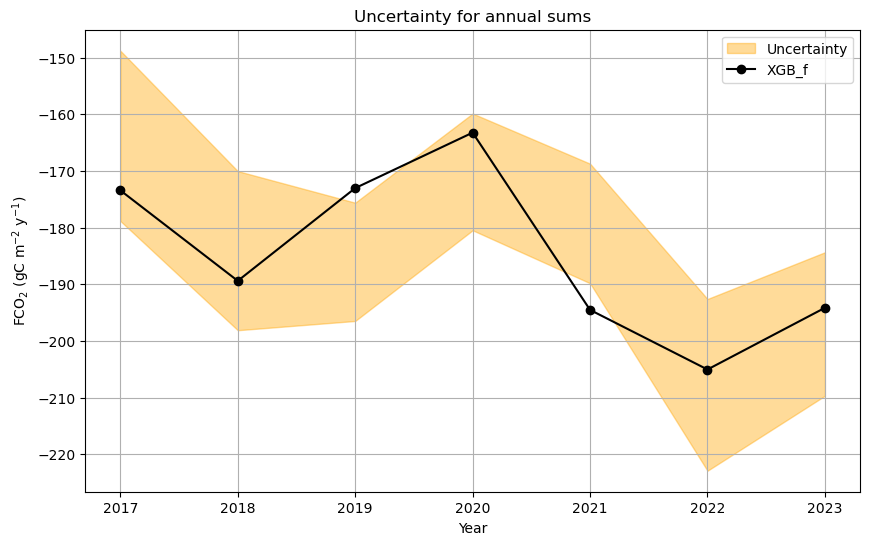

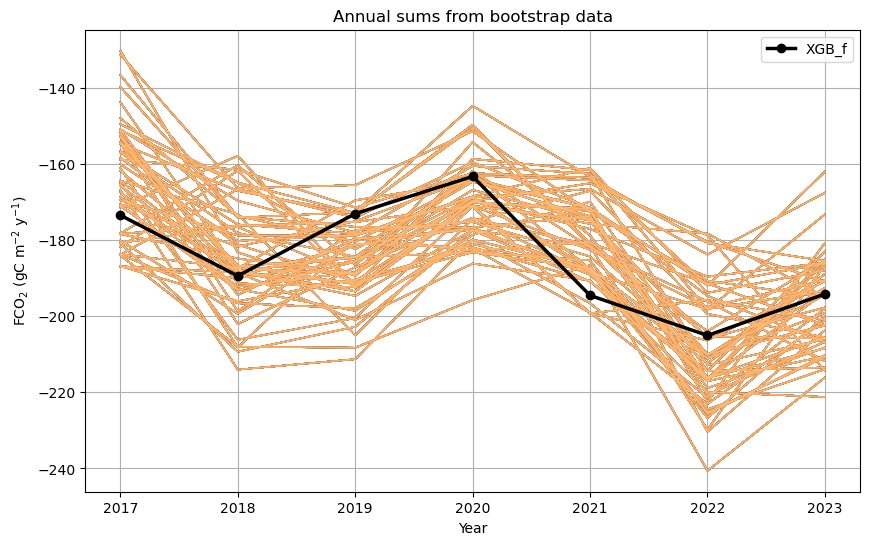

In [14]:
# Visualise the output
import matplotlib.pyplot as plt
# plot 1: barplot for SD of annual sums
plt.figure(figsize=(10, 6))
bars = plt.bar(years, std_vals, color='orange', alpha=0.4)

# Add SD values as text above each bar
for bar, sd in zip(bars, std_vals):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*max(std_vals),  # slightly above the bar
             f'{sd:.0f}', ha='center', va='bottom', fontsize=10)
plt.axhline(y=25, color='red', linestyle='--', linewidth=1.5, label='y = 25')
plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Stand deviation of annual Sums')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# plot 2: annual sums from actual gapfilling vs SD of annual sums
plt.figure(figsize=(10, 6))
# Red shaded area for annual sums from synthetic data
plt.fill_between(years, mean_vals - std_vals, mean_vals + std_vals, color='orange', alpha=0.4, label='Uncertainty')
# Plot the original XGB_FC_f predictions
annual_sum_orig = cal_FC_annual_sum(df_pred_FC, var_name='XGB_f', start_year=years.min(), end_year=years.max(), plot=False)
plt.plot(annual_sum_orig['Year'], annual_sum_orig['annual_sum'], marker='o', linestyle='-', color='black', label='XGB_f')
plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Uncertainty for annual sums')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 3: annual sums from bootstrap data (each bootstrap in different color) ---
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot each bootstrap (each column in annual_values)
n_boot = annual_values.shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, n_boot))  # distinct colors

for i, col in enumerate(annual_values.columns):
    plt.plot(years, annual_values[col], color=colors[i % 20], alpha=0.6, linewidth=1)

# Overlay the original XGB_f line in black (thicker)
annual_sum_orig = cal_FC_annual_sum(df_pred_FC, var_name='XGB_f',
                                    start_year=years.min(), end_year=years.max(), plot=False)
plt.plot(annual_sum_orig['Year'], annual_sum_orig['annual_sum'],
         color='black', linewidth=2.5, marker='o', label='XGB_f')

plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Annual sums from bootstrap data')
plt.legend()
plt.grid(True)
plt.show()


# 08 Important test for uncertainty analysis

In [ ]:
# important test: create a list with raw data, no bootstrapping

def get_raw_data_list(original_data, n_bootstrap=50, gapfill_cols=None, target_col=None):
    """
    Create a list containing clean copies of the original dataset (no bootstrapping or random dropping).
    Removes rows with NaN or inf in the target column.
    """

    df = original_data.copy()

    # Optional: remove rows where all gapfill_cols are NaN
    if gapfill_cols is not None:
        if isinstance(gapfill_cols, str):
            gapfill_cols = [gapfill_cols]
        mask = df[gapfill_cols].isna().all(axis=1)
        df = df.loc[~mask]

    # Handle NaN or inf in the target column
    if target_col is not None and target_col in df.columns:
        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.dropna(subset=[target_col])

    # Return list of identical clean copies
    return [df.copy() for _ in range(n_bootstrap)]

raw_list = get_raw_data_list(
    original_data=site_data,
    n_bootstrap=50,
    gapfill_cols=predictors,
    target_col=y_col  # 👈 important
)

synthetic_predictions = train_on_synthetic_predict(
    site_data, raw_list, predictors, y_col, model_dir
) # Please note: This is based on all predicted values, but not measured + gapfilled

# List to store annual sums for each bootstrap
annual_sums_list = []

for col in synthetic_predictions.columns:
    # Create a temporary dataframe with predictions
    temp_df = site_data.copy()
    temp_df['Pred'] = synthetic_predictions[col]

    # Compute annual sums
    agg = cal_FC_annual_sum(
        data=temp_df,
        var_name='Pred',
        start_year=2017,
        end_year=2023,
        plot = False
    )

    # Keep only Year and annual_sum
    annual_sums_list.append(agg[['Year', 'annual_sum']])

# Combine all bootstraps
all_annual_sums = pd.concat(annual_sums_list, axis=1)

# The concatenation duplicates Year columns, so keep the first one and use the rest as data
years = all_annual_sums.iloc[:, 0]
annual_values = all_annual_sums.iloc[:, 1::2]  # Every second column is annual_sum

# Compute mean and std across bootstraps (synthetic datata) for each year
mean_vals = annual_values.mean(axis=1)
std_vals = annual_values.std(axis=1)


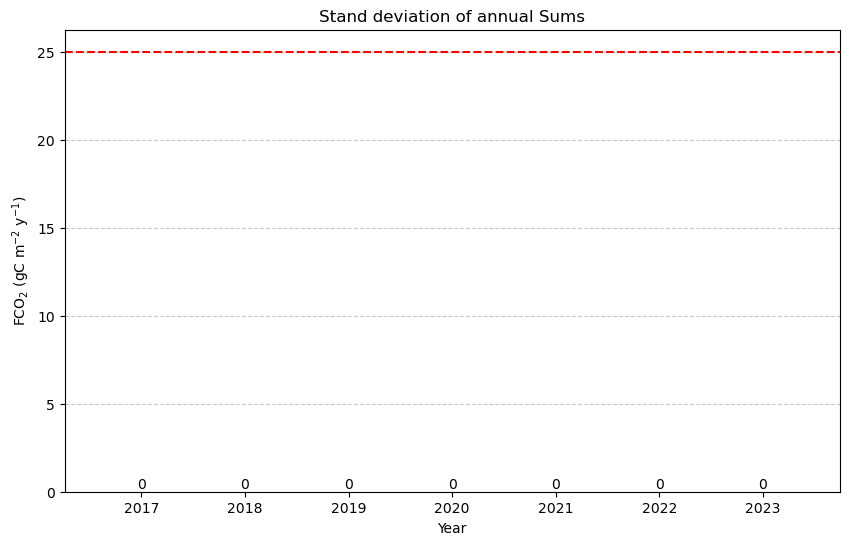

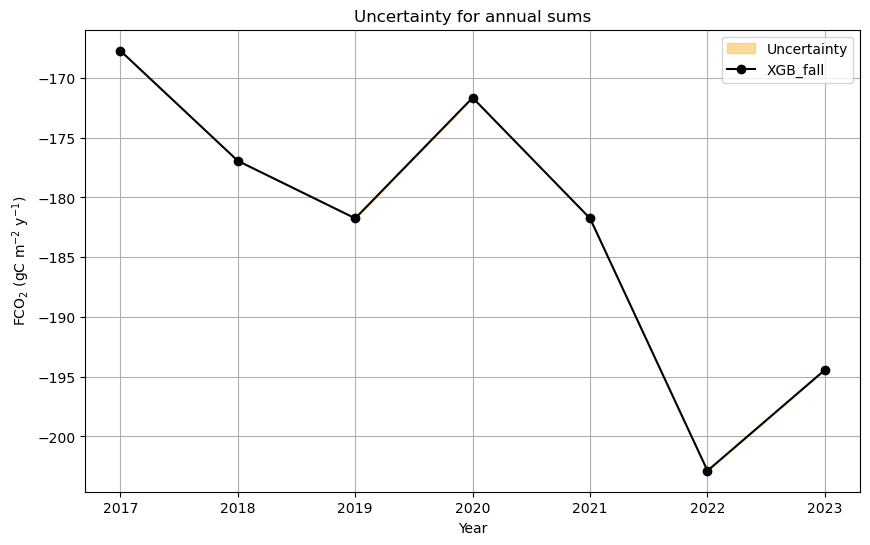

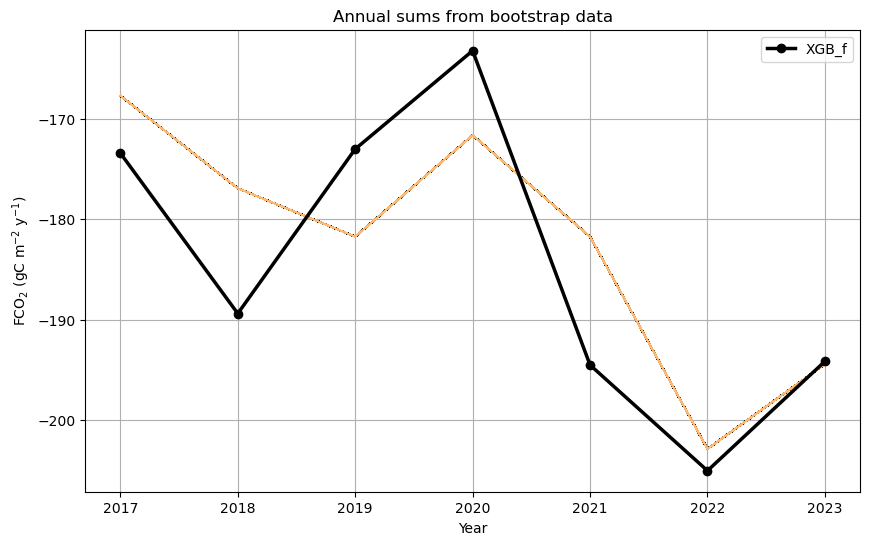

In [20]:
# Visualise the output again, without bootstrapping
import matplotlib.pyplot as plt
# plot 1: barplot for SD of annual sums
plt.figure(figsize=(10, 6))
bars = plt.bar(years, std_vals, color='orange', alpha=0.4)

# Add SD values as text above each bar
for bar, sd in zip(bars, std_vals):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*max(std_vals),  # slightly above the bar
             f'{sd:.0f}', ha='center', va='bottom', fontsize=10)
plt.axhline(y=25, color='red', linestyle='--', linewidth=1.5, label='y = 25')
plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Stand deviation of annual Sums')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# plot 2: annual sums from actual gapfilling vs SD of annual sums
plt.figure(figsize=(10, 6))
# Red shaded area for annual sums from synthetic data
plt.fill_between(years, mean_vals - std_vals, mean_vals + std_vals, color='orange', alpha=0.4, label='Uncertainty')
# Plot the original XGB_FC_f predictions
annual_sum_orig = cal_FC_annual_sum(df_pred_FC, var_name='XGB_fall', start_year=years.min(), end_year=years.max(), plot=False)
plt.plot(annual_sum_orig['Year'], annual_sum_orig['annual_sum'], marker='o', linestyle='-', color='black', label='XGB_fall')
plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Uncertainty for annual sums')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 3: annual sums from bootstrap data (each bootstrap in different color) ---
plt.figure(figsize=(10, 6))

# Plot each bootstrap (each column in annual_values)
n_boot = annual_values.shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, n_boot))  # distinct colors

for i, col in enumerate(annual_values.columns):
    plt.plot(years, annual_values[col], color=colors[i % 20], alpha=0.6, linewidth=1)

# Overlay the original XGB_f line in black (thicker)
annual_sum_orig = cal_FC_annual_sum(df_pred_FC, var_name='XGB_f',
                                    start_year=years.min(), end_year=years.max(), plot=False)
plt.plot(annual_sum_orig['Year'], annual_sum_orig['annual_sum'],
         color='black', linewidth=2.5, marker='o', label='XGB_f')

plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Annual sums from bootstrap data')
plt.legend()
plt.grid(True)
plt.show()
